In [1]:
import os, sys
import time
import numpy as np
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed

notebook_dir = os.getcwd()  # Gets test folder path
project_dir = os.path.dirname(notebook_dir)  # Gets Project folder path
sys.path.append(project_dir)

from subproblems import *
from utils import *

# Global config
BUS_SYS = 33
DATA_DIR = r"D:\Jacky\Python\ADMM_P2P_Python\data"
RUN_ID = datetime.now().strftime("Run_OneSce_%Y%m%d_%H%M%S")

In [2]:
def users_worker(i):
    """Run one prosumer subproblem and return index + results."""
    cost, pros_decisions_new, Pout_new, ui_prosumer = subproblem_prosumer(
        params_prosumer, Pout_aux, i, lam, RHO
    )
    return i, cost, pros_decisions_new, Pout_new, ui_prosumer

In [3]:
SCENARIO = 1000 

RHO = 0.6
MAX_ITER = 5000
PRIMAL_TOL, DUAL_TOL = 1e-3, 1e-3
BATTERY_CAP = 2
P2P_TRADE = (16, 38)
SOLAR_SCALER = 1.5

logger = setup_logger(name=RUN_ID, log_file=f"{RUN_ID}.log")
logger.info(f"Initialized single-scenario ADMM run: {RUN_ID}")

2025-11-20 14:29:47,398 - Run_OneSce_20251120_142947 - INFO - Initialized single-scenario ADMM run: Run_OneSce_20251120_142947


In [4]:
data = load_scenario_data(DATA_DIR, BUS_SYS)
hour, num_user = data["power_consumption"].shape
logger.info(f"Loaded {num_user} prosumers × {hour} hours dataset.")

2025-11-20 14:29:47,659 - Run_OneSce_20251120_142947 - INFO - Loaded 32 prosumers × 48 hours dataset.


In [5]:
# -----------------------------
# SCENARIO INITIALIZATION
# -----------------------------
solar = data["solar"][SCENARIO - 1, :] * SOLAR_SCALER
net_load = data["power_consumption"].T.copy()
pros_solar = int(np.ceil(num_user / 2)) - 1 # to match with Julia 1-inclusive indexing 
net_load[pros_solar:, :] -= solar[np.newaxis, :]

# == Scenario-specific parameters ==
total_excess = np.sum(np.where(net_load < 0, -net_load, 0), axis=0)
total_deficiency = np.sum(np.where(net_load > 0,  net_load, 0), axis=0)

# === CES battery bounds ===
ub_CES = np.full((hour, num_user), BATTERY_CAP)
lb_CES = np.zeros((hour, num_user))

ub_CESc = np.full((hour, num_user), BATTERY_CAP / 3)  # charging bound
lb_CESc = np.zeros((hour, num_user))

ub_CESd = np.full((hour, num_user), BATTERY_CAP / 3)  # discharging bound
lb_CESd = np.zeros((hour, num_user))

# === Initialize other key parameters ===
beta_tnb = 1
P_CES0 = np.full(num_user, BATTERY_CAP / 2)
efficiency_CES = 1.0

# === Build prosumer parameters ===
params_prosumer = {
    "ub_CES": ub_CES,
    "lb_CES": lb_CES,
    "ub_CESc": ub_CESc,
    "lb_CESc": lb_CESc,
    "ub_CESd": ub_CESd,
    "lb_CESd": lb_CESd,
    "hour": hour,
    "beta_tnb": beta_tnb,
    "CES0": P_CES0,
    "P2PTrade": P2P_TRADE,
    "efficiency_CES": efficiency_CES,
    "buy_priority": data["buy_priority"],
    "sell_priority": data["sell_priority"],
    "load_demamd": net_load.T,  # matches Julia's net_load'
}

# === Build grid parameters ===
params_grid = {
    "hour": hour,
    "num_user": num_user,
    "ptdf": data["ptdf"],
    "num_bus": data["nb_bus"],
    "num_branch": data["nb_branch"],
    "branch_limit": data["branch_limit"],
    "ub_CES": ub_CES,
    "lb_CES": lb_CES,
    "ub_CESc": ub_CESc,
    "lb_CESc": lb_CESc,
    "ub_CESd": ub_CESd,
    "lb_CESd": lb_CESd,
    "buy_priority": data["buy_priority"],
    "sell_priority": data["sell_priority"],
    "efficiency_CES": efficiency_CES,
    "load_demamd": net_load.T,
    "loc_prosumer": np.eye(num_user, data["nb_bus"]),  # same as loc_prosumer[i,i+1] = 1
    "P2PTrade": P2P_TRADE,
}


In [6]:
num_dec = 4
lam = np.zeros((num_dec * hour, num_user))
Pout = np.zeros((num_dec * hour, num_user))
Pout_aux = np.zeros_like(Pout)
pros_decisions = np.zeros((7 * hour, num_user))

lam_all = []
Pout_all = []
Pout_aux_all = []
P_dec_all = []
primal_residuals = [1.0]
dual_residuals = []
primal_errors, dual_errors = [], []
obj_all = []

In [7]:
iteration = 1
converged = False
start_time = time.time()
while not converged and iteration < MAX_ITER:
    # # === Serial prosumer subproblem solving ===
    # for i in range(num_user):
    #     cost, pros_decisions_new, Pout_new, _ = subproblem_prosumer(
    #         params_prosumer, Pout_aux, i, lam, RHO
    #     )
    #     Pout[:, i] = Pout_new
    #     pros_decisions[:, i] = pros_decisions_new
    
    # === Multi-threaded prosumer subproblem solving ===
    with ThreadPoolExecutor() as ex:
        futures = [ex.submit(users_worker, i) for i in range(num_user)]

        for fut in as_completed(futures):
            i, cost_i, pros_decisions_new, Pout_new, ui_prosumer = fut.result()

            # write into the correct column (same as your serial code)
            Pout[:, i] = Pout_new
            pros_decisions[:, i] = pros_decisions_new

            # If you want to store per-user cost / ui, do it here:
            # cost_vec[i] = cost_i
            # ui_all[:, :, i] = ui_prosumer

    # after all threads finish, snapshot for history
    Pout_all.append(Pout.copy())
    P_dec_all.append(pros_decisions.copy())

    obj_g, grid_decision,Pout_aux, _ = subproblem_grid_operator(
        params_grid, Pout, lam, RHO
    )
    Pout_aux_all.append(Pout_aux.copy())

    lam_last = lam.copy()
    lam = lam + RHO * (Pout_aux - Pout)
    lam_all.append(lam.copy())
    
    p_err, d_err, p_res, d_res = convergence_check(Pout, Pout_aux, lam, lam_last, RHO)
    primal_errors.append(p_err)
    dual_errors.append(d_err)
    primal_residuals.append(p_res)
    dual_residuals.append(d_res)
    obj_val = obj_function(Pout_aux, pros_decisions, data["buy_bp"], data["sell_bp"], beta_tnb=1)
    obj_all.append(obj_val)

    logger.info(f"[Iter {iteration}] p_res={p_res:.3e}, d_res={d_res:.3e}, obj={obj_val}")
    if p_res < PRIMAL_TOL and d_res < DUAL_TOL:
        converged = True
    iteration += 1

exec_time = time.time() - start_time
logger.info(f"[DONE] Scenario {SCENARIO} completed | {iteration} iters | {exec_time:.2f}s")

Set parameter Username
Set parameter Username
Academic license - for non-commercial use only - expires 2025-12-06
Set parameter Username
Set parameter Username
Set parameter Username
Academic license - for non-commercial use only - expires 2025-12-06
Academic license - for non-commercial use only - expires 2025-12-06
Academic license - for non-commercial use only - expires 2025-12-06
Set parameter Username
Academic license - for non-commercial use only - expires 2025-12-06
Academic license - for non-commercial use only - expires 2025-12-06
Freeing default Gurobi environment
Freeing default Gurobi environment
Freeing default Gurobi environment
Freeing default Gurobi environment
Freeing default Gurobi environment


2025-11-20 14:29:50,290 - Run_OneSce_20251120_142947 - INFO - [Iter 1] p_res=1.843e+00, d_res=6.636e-01, obj=417.62539104888924
2025-11-20 14:29:52,956 - Run_OneSce_20251120_142947 - INFO - [Iter 2] p_res=2.194e+00, d_res=7.899e-01, obj=375.8613315256435
2025-11-20 14:29:55,673 - Run_OneSce_20251120_142947 - INFO - [Iter 3] p_res=2.440e+00, d_res=8.782e-01, obj=361.8803851466174
2025-11-20 14:29:58,115 - Run_OneSce_20251120_142947 - INFO - [Iter 4] p_res=2.372e+00, d_res=8.538e-01, obj=359.5558284406005
2025-11-20 14:30:00,669 - Run_OneSce_20251120_142947 - INFO - [Iter 5] p_res=2.181e+00, d_res=7.851e-01, obj=361.79731591401946
2025-11-20 14:30:03,392 - Run_OneSce_20251120_142947 - INFO - [Iter 6] p_res=1.967e+00, d_res=7.082e-01, obj=365.65250884635105
2025-11-20 14:30:06,244 - Run_OneSce_20251120_142947 - INFO - [Iter 7] p_res=1.720e+00, d_res=6.193e-01, obj=371.13818082109475
2025-11-20 14:30:08,181 - Run_OneSce_20251120_142947 - INFO - [Iter 8] p_res=1.504e+00, d_res=5.416e-01, ob

In [8]:
Pout_all = np.stack(Pout_all, axis=2)
lam_all = np.stack(lam_all, axis=2)
Pout_aux_all = np.stack(Pout_aux_all, axis=2)
P_dec_all = np.stack(P_dec_all, axis=2)

Pout_all.shape, Pout_aux_all.shape, lam_all.shape, P_dec_all.shape

((192, 32, 751), (192, 32, 751), (192, 32, 751), (336, 32, 751))

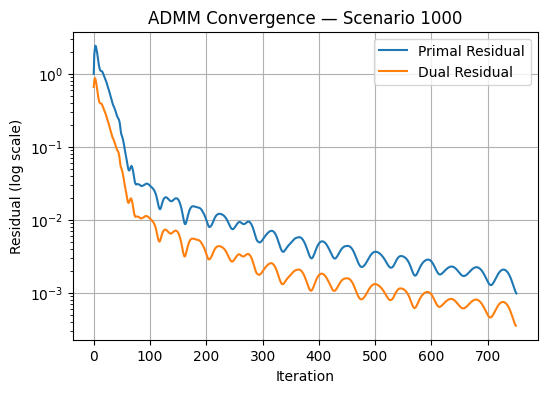

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.semilogy(primal_residuals, label="Primal Residual")
plt.semilogy(dual_residuals, label="Dual Residual")
plt.title(f"ADMM Convergence — Scenario {SCENARIO}")
plt.xlabel("Iteration")
plt.ylabel("Residual (log scale)")
plt.legend()
plt.grid(True)

figure_path = os.path.join(project_dir, 'output','logs',f'{RUN_ID}_conv_res.png')
plt.savefig(figure_path)

plt.show()

In [10]:
from utils import *
prt_comp = [True, project_dir, RUN_ID]

prosumer_cost, TNBearn = profit_cal(
    pros_decisions, Pout_aux, data['buy_priority'], data['sell_priority'],
    total_excess, net_load,
    data["buy_bp"], data["sell_bp"], [0.57, 0.15],
    data["power_consumption"], SOLAR_SCALER, BATTERY_CAP, P2P_TRADE, print_result=prt_comp
)

oneSave(
    Pout_aux, lam, pros_decisions, grid_decision,
    exec_time, iteration, primal_errors, dual_errors,
    primal_residuals, dual_residuals, obj_all,
    data["buy_priority"], data["sell_priority"], net_load.T, params_grid,
    path="OneScenario", run_id=RUN_ID
)

logger.info(f"[SAVE] Scenario {SCENARIO} results saved successfully.")

2025-11-20 15:01:02,624 - Run_OneSce_20251120_142947 - INFO - [SAVE] Scenario 1000 results saved successfully.


[oneSave] Scenario results saved successfully at D:/Jacky/Python/ADMM_P2P_Python/output/OneScenario\Run_OneSce_20251120_142947


In [11]:
nb_hour, nb_prosumer = data['power_consumption'].shape
hour = nb_hour

# --- Slice decision variables (matching Julia indexing but 0-based) ---
Result_Grid_buy  = pros_decisions[0*hour:1*hour, :]
Result_Grid_sell = pros_decisions[1*hour:2*hour, :]
Result_bat_lv    = pros_decisions[2*hour:3*hour, :]  # not used further but kept

Result_Charge    = Pout_aux[0*hour:1*hour, :]
Result_Discharge = Pout_aux[1*hour:2*hour, :]
Result_P2P_buy   = Pout_aux[2*hour:3*hour, :]
Result_P2P_sell  = Pout_aux[3*hour:4*hour, :]

# --- Prices and net load with battery ---
# (assumes buy_bp, sell_bp: (nb_hour, nb_prosumer) or compatible)
final_buy_price  = np.sum(data['buy_bp'], axis=0) / nb_prosumer   # shape (nb_hour,)
final_sell_price = np.sum(data['sell_bp'], axis=0) / nb_prosumer  # shape (nb_hour,)
print(final_buy_price.shape, final_sell_price.shape)
# net_load is assumed (nb_prosumer, nb_hour) like in Julia
NetLoad = net_load.T + Result_Charge - Result_Discharge   # (nb_hour, nb_prosumer)

# --- Priority matrices ---
nbBuyPrio  = prio_conversion(data['buy_priority'],  total_excess, NetLoad, 0)
nbSellPrio = prio_conversion(data['sell_priority'], total_excess, NetLoad, 1)

# --- Aggregate energy quantities ---
totalPower = np.sum(data['power_consumption'], axis=0)     # (N,) total consumption
totalNEM   = np.sum(net_load.T, axis=0)            # (N,)

P2P_start, P2P_end = P2P_TRADE          # assumed Python-style: start inclusive, end exclusive
# If your P2PTrade is Julia-style (1-based inclusive), change to:
# P2P_start, P2P_end = P2PTrade[0] - 1, P2PTrade[1]

# Broadcast prices to (time, prosumer)
fb = final_buy_price[:, np.newaxis]
fs = final_sell_price[:, np.newaxis]
print(fb.shape, fs.shape)

totalP2P = np.sum(
    (Result_P2P_buy[P2P_start:P2P_end, :]  * fb[P2P_start:P2P_end, :]) -
    (Result_P2P_sell[P2P_start:P2P_end, :] * fs[P2P_start:P2P_end, :]) +
    (Result_Grid_buy[P2P_start:P2P_end, :] * 0.57) -
    (Result_Grid_sell[P2P_start:P2P_end, :] * 0.15),
    axis=0,
)

(48,) (48,)


NameError: name 'prio_conversion' is not defined

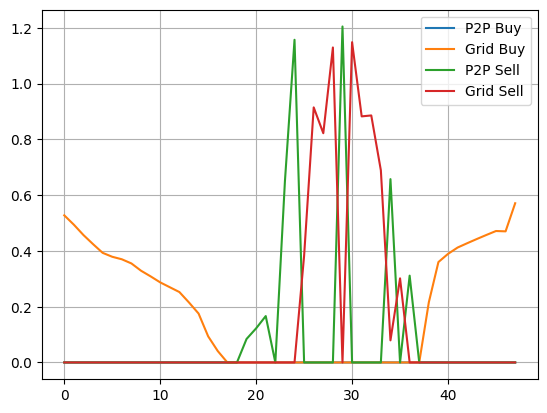

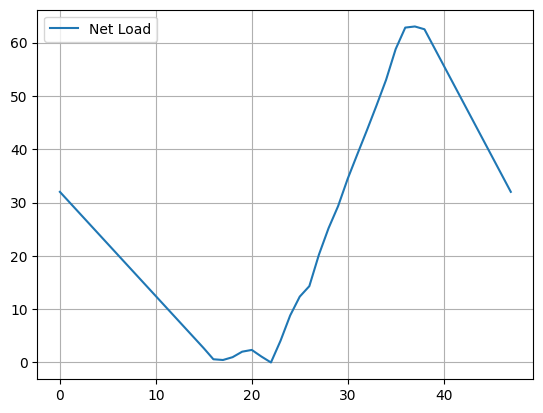

In [ ]:
users_id = 16
plt.figure()
plt.plot((Result_P2P_buy[:,users_id]), label='P2P Buy')
plt.plot((Result_Grid_buy[:,users_id]), label='Grid Buy')
plt.plot((Result_P2P_sell[:,users_id]), label='P2P Sell')
plt.plot((Result_Grid_sell[:,users_id]), label='Grid Sell')
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(np.sum(Result_bat_lv,axis=1), label='Battery Capacity')
plt.grid(True)
plt.legend()
plt.show()